# §1 SINDy and its Extensions

This section aims to introduce the reader to SINDy and its selected extensions. The tutorials will cover:

* 1-1 Introduction to SINDy - A brief introduction to SINDy and how to run your first SINDy example.
* 1-2 Ill-Conditioned Regression - Demonstrates commonly faced issues when applying SINDy and how to address them.
* 1-3 Embedding Prior Knowledge - Presents how to bake in prior physics knowledge and constraints within SINDy.
* 1-4 Choice of Coordinate Basis - Selection of coordinate basis with informed choices, or data-driven methods.
* 1-5 Handling Noisy Data - How to deal with noisy datasets?
* 1-6 SINDy and Controls - Introducing SINDy with controls (SINDyc) formulation and how it may integrated with model predictive control (MPC).
* 1-7 Weak Form SINDy - Presents the weak formulation of SINDy which circumvents the need to compute the time derivative from noisy data.
  * 1-7-1 Weak form for ODEs - Covers weak form extension for ODEs.
  * 1-7-2 Weak form for PDEs - Covers weak form extension for PDEs.
* 1-8 Ensembling Methods - Introduces SINDy with ensembling methods.
  * 1-8-1 Ensemble SINDy - Demonstrates the use of ensembling for noise mitigation and uncertainty quantification.
  * 1-8-2 Active SINDy - Demonstrates the use of ensembling to guide active learning.

---

# Introduction to SINDy

This is the first tutorial of the repository and aims to build up fundamental knowledge required to build a basic SINDy model. In this tutorial, we seek to understand
1. The formulation of SINDy and how data is prepared for it.
2. Numerical differentiation via finite difference.
3. Construction of candidate function libraries, using polynomial basis functions as an example.
4. Sequentially thresholded least squares (STLSQ), a sparse regression optimization algorithm.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps
import warnings
from IPython.display import display, Math

from sindy.odes import lorenz
from sindy.ivp_solvers import rk4
from sindy.library import poly_lib, trig_lib
from sindy.optimizer import stlsq
from sindy.plot_utils import init_plt_format, visualize_ode_3d
from sindy.utils import set_seed, print_latex_eqn
from sindy.metrics import rel_fro_err

warnings.filterwarnings('ignore', category=RuntimeWarning)
init_plt_format()
set_seed(0)

# Formulation of SINDy

The Sparse Identification of Nonlinear Dynamics (SINDy) is a sparse regression based method that can discover the underlying governing equations using measured time series data from dynamical systems. The core motivation of SINDy is to discover interpretable mathematical differential equations that can describe a given time-series data. To be interpretable, the equation structure itself must be sparse, describing only the key dynamics within the system and no more. And if the true form of the equation can be discovered, data can be extrapolated well beyond the original training data domain using the learned model.

We will first provide a brief overview of the SINDy method and required definitions, followed afterwards by a more detailed explanation of its core components:
* Numerical differentiation
* Candidate function libraries
* Sparse optimization

Suppose that we have a dynamical system defined by states $\boldsymbol{x}(t) \in \mathbb{R}^n$ (which is a state vector with $n$ variables) such that
$$\frac{d}{dt} \boldsymbol{x}(t) = \boldsymbol{f}(\boldsymbol{x}(t))$$

where $f$ is potentially a nonlinear function.


> For instance, the voltage decay in a RC circuit (resistor-capacitor circuit) can be defined as $$\frac{dV}{dt} = f(V(t)) = -V(t)/RC,$$ and its time-series data can be formatted into a column vector $$V(t) = \begin{bmatrix} V(t_1) \\ V(t_2) \\ \vdots \\ V(t_m) \end{bmatrix}.$$


For a general dynamical system, we may have $n$ number of states in the system, with $m$ number of data measurements. We define the state vector as

$$\boldsymbol{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}.$$

Before we formulate the SINDy regression problem, we first collate our measured data points along with their time derivatives into matrices such that

$$
\begin{aligned}
    X &=
    \begin{bmatrix}
        | & | & & | \\
        \boldsymbol{x}_1(t) & \boldsymbol{x}_2(t) & \dots & \boldsymbol{x}_n(t) \\
        | & | & & | \\
    \end{bmatrix}
    = \begin{bmatrix}
        \boldsymbol{x}_1(t_1) & \boldsymbol{x}_2(t_1) & \dots & \boldsymbol{x}_n(t_1) \\
        \boldsymbol{x}_1(t_2) & \boldsymbol{x}_2(t_2) & \dots & \boldsymbol{x}_n(t_2) \\
        \vdots & \vdots & \ddots & \vdots \\
        \boldsymbol{x}_1(t_m) & \boldsymbol{x}_2(t_m) & \dots & \boldsymbol{x}_n(t_m)
    \end{bmatrix}, \\
    \dot{X} &=
    \begin{bmatrix}
        | & | & & | \\
        \dot{\boldsymbol{x}}_1(t) & \dot{\boldsymbol{x}}_2(t) & \dots & \dot{\boldsymbol{x}}_n(t) \\
        | & | & & | \\
    \end{bmatrix}
    = \begin{bmatrix}
        \dot{\boldsymbol{x}}_1(t_1) & \dot{\boldsymbol{x}}_2(t_1) & \dots & \dot{\boldsymbol{x}}_n(t_1) \\
        \dot{\boldsymbol{x}}_1(t_2) & \dot{\boldsymbol{x}}_2(t_2) & \dots & \dot{\boldsymbol{x}}_n(t_2) \\
        \vdots & \vdots & \ddots & \vdots \\
        \dot{\boldsymbol{x}}_1(t_m) & \dot{\boldsymbol{x}}_2(t_m) & \dots & \dot{\boldsymbol{x}}_n(t_m)
    \end{bmatrix}.
\end{aligned}
$$

SINDy assumes $\boldsymbol{f}$ can be defined or approximated using linear combinations of nonlinear candidate functions $\theta$ provided in a library matrix $\Theta(X) \in \mathbb{R}^{m \times l}$ where

$$
\Theta(X) = \begin{bmatrix}
    | & | & & | \\
    \theta_1(X) & \theta_2(X) & \dots & \theta_{l}(X) \\
    | & | & & |
\end{bmatrix},
$$

which contains $l$ number of candidate functions. For example, functions of polynomial basis ($x, x^2, x^3$, ...) or Fourier basis ($\sin(x), \cos(x), \sin(2x), \cos(2x)$, ...) can be included.

SINDy aims to discover a sparse coefficient matrix $\Xi \in \mathbb{R}^{l \times n}$ where

$$
\Xi = \begin{bmatrix}
    | & | & & | \\
    \xi_1 & \xi_2 & \dots & \xi_n \\
    | & | & & |
\end{bmatrix},
$$

such that the final dynamical system may be approximated as

$$\dot{X} \approx \Theta(X) \Xi.$$

> In a classical dynamic system formulation, only the first order derivatives of the states are defined. If a second order system is involved such as a mass-spring system defined by $\ddot{z} = -\frac{k}{m}z$, the system state can be expanded such that $\boldsymbol{x} = \begin{bmatrix} x_1 & x_2 \end{bmatrix}^T = \begin{bmatrix} \dot{z} & z \end{bmatrix}^T$. The dynamical system is then defined as $$\dot{\boldsymbol{x}} = \frac{d}{dt} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} -\frac{k}{m}x_2 \\ x_1 \end{bmatrix}.$$ In SINDy's formulation, one may also opt to feed in the second order derivative and apply sparse regression directly. For instance, in this case we assume the regression problem of the form $$\ddot{X} \approx \Theta(X) \Xi.$$

## Numerical Differentiation using Finite Difference

Often, the time derivatives of measurements cannot be measured directly and must be computed numerically. A straight forward method is with [finite difference method](https://en.wikipedia.org/wiki/Finite_difference_method) which allows us to numerically approximate the derivatives of a function on a discrete grid. It uses neighboring points to compute the local gradient information. A 2nd order accurate central finite difference for 1st order derivative is given by

$$ \frac{d}{dt} f(t_i) \approx \frac{f(t_{i+1}) - f(t_{i-1})}{2 \Delta t} $$

where $\Delta t$ is the time discretization interval (or spatial grid interval where spatial derivatives are concerned). This particular formula assumes a uniform grid discretization. Higher order accuracies are preferred but requires the use of more stencil points. For instance, the 4th order accuracy central finite difference scheme for 1st order derivative is given by

$$ \frac{d}{dt} f(t_i) \approx \frac{f(t_{i-2}) - 8f(t_{i-1}) + 8f(t_{i+1}) - f(t_{i+2})}{12 \Delta t} $$

and requires 2 additional stencil points. Finite difference scheme of any arbitrary derivative and accuracy order can be derived using the Taylor expansion, even with non-uniform grid intervals.

However, finite difference performs poorly with non-smooth data (even worse for data with discontinuities), and introduces an artificial smoothing effect. Utilizing higher order accuracy may also be problematic as it increases the padding requirement at the boundaries of the dataset; though this can be mitigated through the use of biased (one-sided) finite difference method or the use of periodic boundary conditions where applicable.

Let us demonstrate an application of a 2nd order accurate 1st order derivative method on an exponential function.

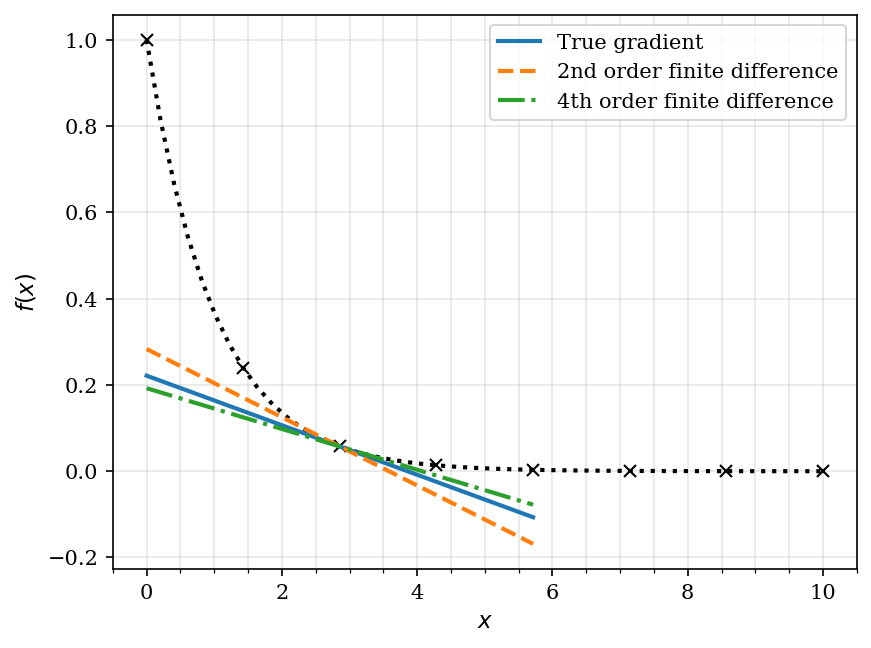

In [2]:
# Define differentiation point index (must have two spare stencil points on
# either side)
fd_idx: int = 2

# Define t vector and number of discrete data points
m: int = 8
t: np.ndarray = np.linspace(0, 10, m)
t_idx: float = t[fd_idx]
dt: float = t[1] - t[0]

# Define function f
f = lambda x: np.exp(-x)

# Validate that two spare stencil points exist on either side of the query
# point
assert fd_idx >= 2 and fd_idx <= m-3, (
    'fd_idx must have two spare stencil points on either side!'
)

# Evaluate function f at the discrete points
y: np.ndarray = f(t)
y_idx: float = y[fd_idx]

# Obtain true derivative at the query point
true_diff: float = -np.exp(-t[fd_idx])

# Obtain the approximated gradient with different orders of finite difference
fd2_diff: float = (y[fd_idx+1] - y[fd_idx-1]) / (2*dt)
fd4_diff: float = (y[fd_idx-2] - 8*y[fd_idx-1] + 8*y[fd_idx+1] - y[fd_idx+2]) \
    / (12*dt)

# Visualize the finite difference method
plt.figure()
plt.plot(t, y, 'kx')
plt.plot(np.linspace(t[0],t[-1]), f(np.linspace(t[0],t[-1])), 'k:')
plt.plot(
    [t_idx-2*dt, t_idx+2*dt], [y_idx - true_diff*2*dt, y_idx + true_diff*2*dt],
    '-', label='True gradient'
)
plt.plot(
    [t_idx-2*dt, t_idx+2*dt], [y_idx - fd2_diff*2*dt, y_idx + fd2_diff*2*dt],
    '--', label='2nd order finite difference'
)
plt.plot(
    [t_idx-2*dt, t_idx+2*dt], [y_idx - fd4_diff*2*dt, y_idx + fd4_diff*2*dt],
    '-.', label='4th order finite difference'
)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend();

On a smooth function such as an exponential function, we can obtain a relatively accurate gradient. The error reduces with a higher order scheme.

Now, let us demonstrate the application of finite difference on a rapidly changing function of the form $f(t) = tanh(10t)$.

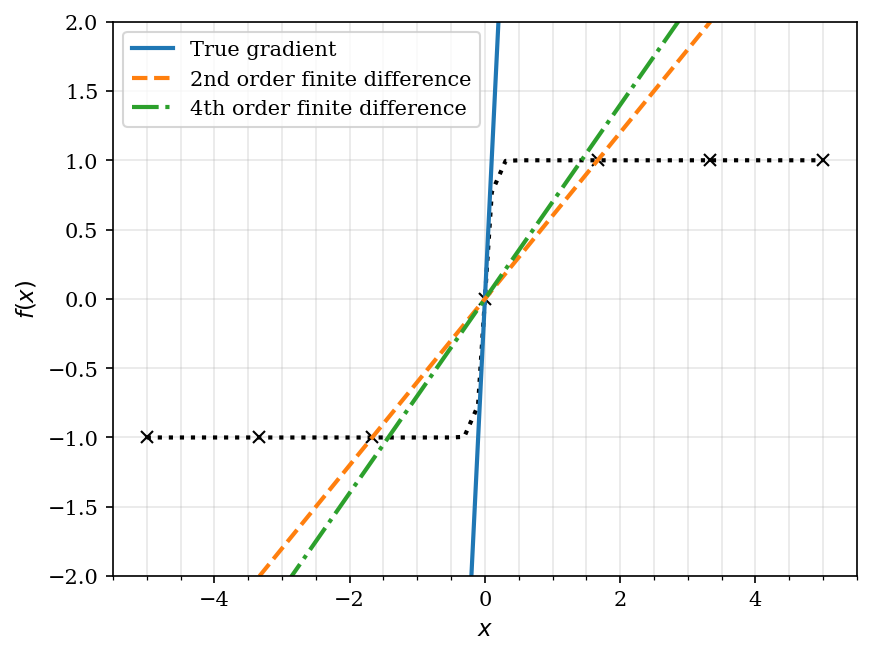

In [3]:
# Define differentiation point index (must have two spare stencil points on
# either side)
fd_idx: int = 3

# Define t vector and number of discrete data points
m: int = 7
t: np.ndarray = np.linspace(-5, 5, m)
t_idx: float = t[fd_idx]
dt: float = t[1] - t[0]

# Define function f
squash_fac: float = 10
f = lambda x: np.tanh(squash_fac*x)

# Validate that two spare stencil points exist on either side of the query
# point
assert fd_idx >= 2 and fd_idx <= m-3, (
    'fd_idx must have two spare stencil points on either side!'
)

# Evaluate function f at the discrete points
y: np.ndarray = f(t)
y_idx: float = y[fd_idx]

# Obtain true derivative at the query point
true_diff: float = squash_fac*np.cosh(squash_fac*t[fd_idx])**-2

# Obtain the approximated gradient with different orders of finite difference
fd2_diff: float = (y[fd_idx+1] - y[fd_idx-1]) / (2*dt)
fd4_diff: float = (y[fd_idx-2] - 8*y[fd_idx-1] + 8*y[fd_idx+1] - y[fd_idx+2]) \
    / (12*dt)

# Visualize the finite difference method
plt.figure()
plt.plot(t, y, 'kx')
plt.plot(np.linspace(t[0],t[-1]), f(np.linspace(t[0],t[-1])), 'k:')
plt.plot(
    [t_idx-2*dt, t_idx+2*dt], [y_idx - true_diff*2*dt, y_idx + true_diff*2*dt],
    '-', label='True gradient'
)
plt.plot(
    [t_idx-2*dt, t_idx+2*dt], [y_idx - fd2_diff*2*dt, y_idx + fd2_diff*2*dt],
    '--', label='2nd order finite difference'
)
plt.plot(
    [t_idx-2*dt, t_idx+2*dt], [y_idx - fd4_diff*2*dt, y_idx + fd4_diff*2*dt],
    '-.', label='4th order finite difference'
)
plt.ylim([-2,2])
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend();

Finite difference performs relatively poorly with rapidly changing data due to its smoothing effect, or with noisy data as we shall soon see in the noisy [data tutorial](./1-5%20Handling%20Noisy%20Data.ipynb). This motivates the need to implement methods that either smoothens out noisy data or bypasses the need for numerical differentiation.

Whilst the `FiniteDifference` class in PySINDy is designed to be parsed into PySINDy's `SINDy` object (see [PySINDy documentations](https://pysindy.readthedocs.io/en/latest/summary.html)). It may also be employed separately to numerically differentiate data to an arbitrary order and order of accuracy, with configurable boundary condition. For instance,

```python
xdot = ps.FiniteDifference(order=4, d=1)._differentiate(x, t)
```

computes the 4th order accurate 1st order derivative data.

## Candidate Function Library

The candidate function library matrix $\Theta(X)$ with $l$ number of candidate functions is selected based on prior knowledge of the system at hand. A common choice of library function is the polynomial basis library which contains permutations of polynomial variables. This is commonly found in many dynamical systems such as the Lorenz equations given by

$$
\begin{aligned}
    \dot{x} &= 10(y-x) \\
    \dot{y} &= x(28-z)-y \\
    \dot{z} &= xy - \frac{8}{3}z,
\end{aligned}
$$

which contains both linear and quadratic terms.

Suppose that we are only given a sample time series trajectory such as the one illustrated below:

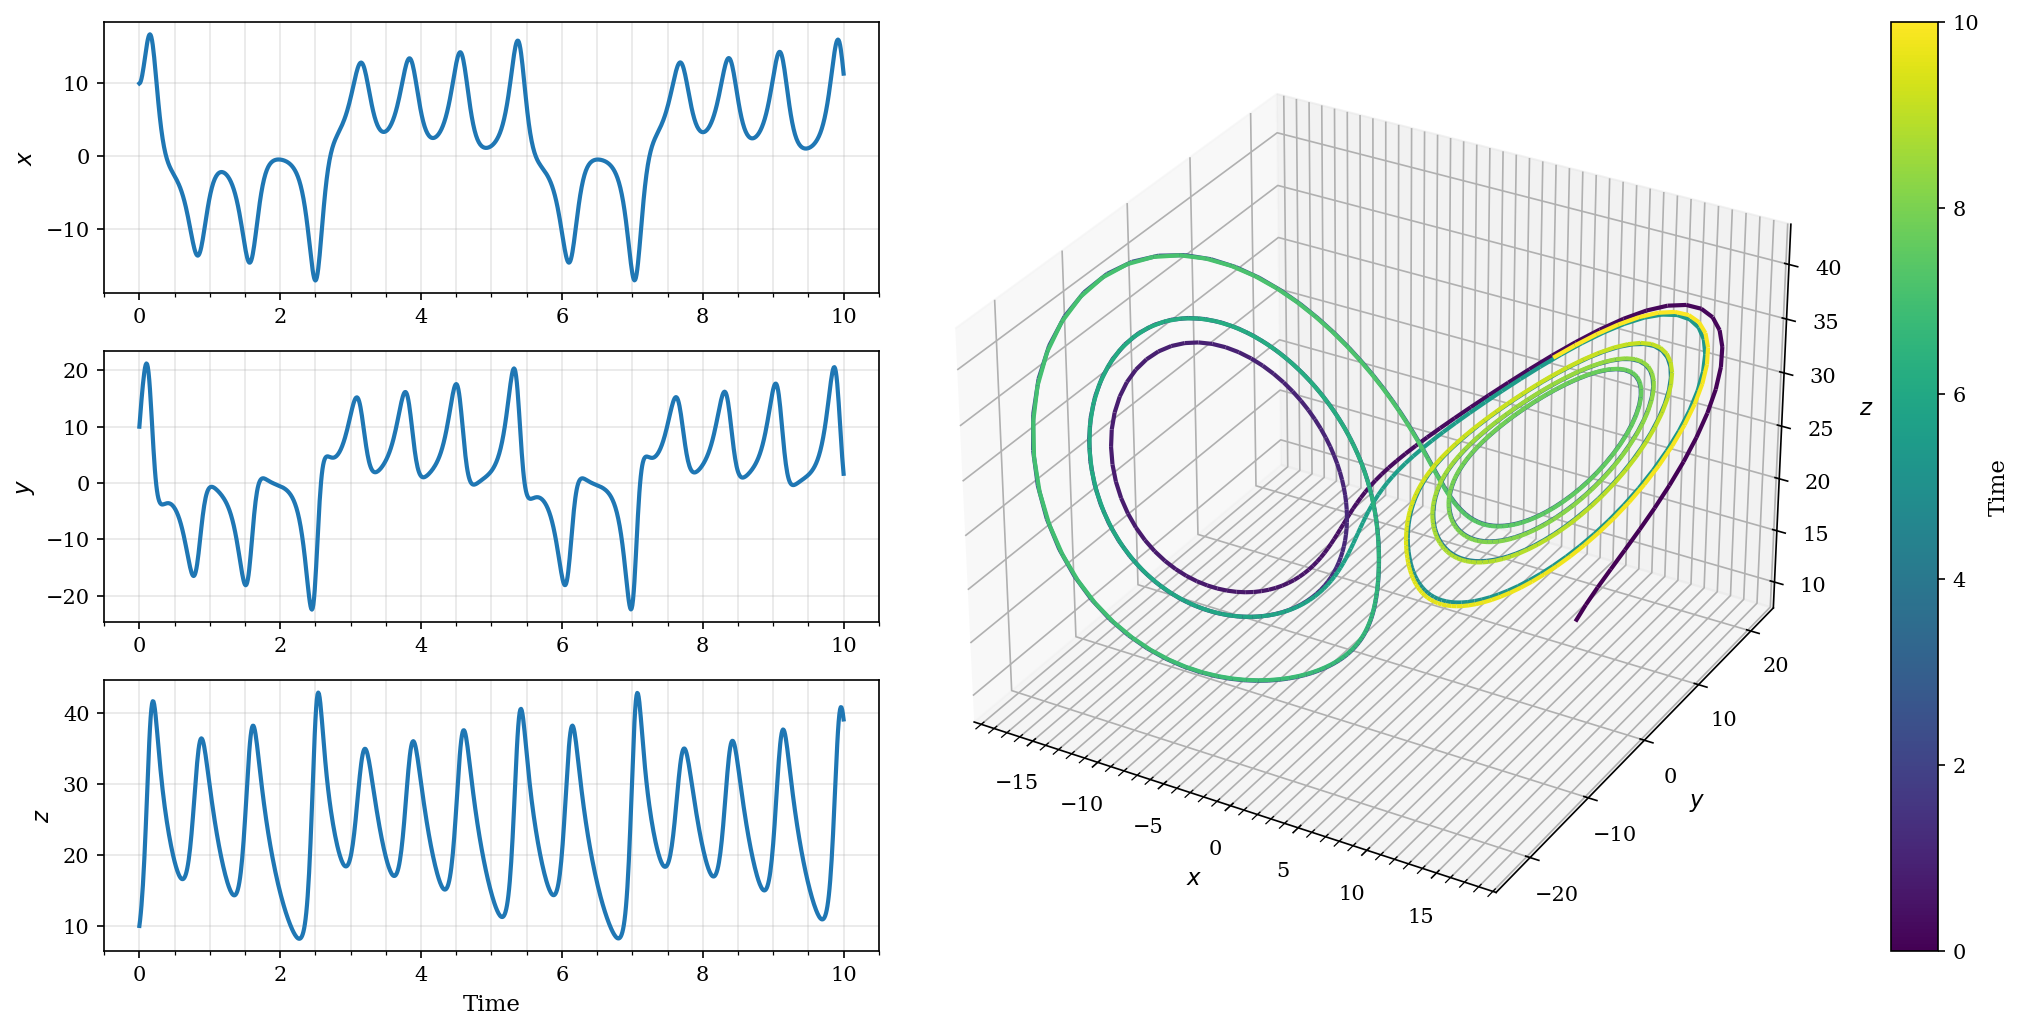

In [4]:
t, x = rk4(lorenz, 10, np.array([10, 10, 10]))
visualize_ode_3d(x, t)

We can accurately recover the original Lorenz equation purely from data as long as our candidate function library contains polynomial basis functions of at least the 2nd order. For instance, if we choose to use a 3rd order polynomial library, we would include the following functions within our library:

In [5]:
lib, lib_names = poly_lib(x, 3, False, ['x', 'y', 'z'])
display(Math(', '.join(lib_names)))

<IPython.core.display.Math object>

We have assembled a candidate function library matrix $\Theta \in \mathbb{R}^{m \times l}$, let us view the first few rows and columns of the matrix.

In [6]:
n_display_funcs = 6
display(pd.DataFrame(
    lib[:, :n_display_funcs].round(3),
    columns=lib_names[:n_display_funcs]
))

,x,y,z,x^2,x y,x z
0,10.000,10.000,10.000,100.000,100.000,100.000
1,10.081,11.657,10.810,101.623,117.514,108.969
2,10.308,13.235,11.777,106.250,136.425,121.395
3,10.660,14.736,12.914,113.627,157.080,137.660
4,11.117,16.152,14.234,123.582,179.561,158.240
...,...,...,...,...,...,...
996,14.715,8.330,40.870,216.538,122.580,601.417
997,14.014,6.405,40.839,196.380,89.755,572.301
998,13.202,4.621,40.504,174.290,61.008,534.727
999,12.306,3.022,39.918,151.448,37.193,491.244


Each column within the matrix represents the corresponding candidate function, which spans across all data samples in the time-series data.

Whilst it may be tempting to include as many functions as possible within the library to discover any equations, it will likely result in an ill-conditioned regression problem. For instance, $x \approx x^3 \approx sin(x)$ for small values of x, which makes it difficult for the algorithm to disambiguate between similar terms. The [condition number](https://en.wikipedia.org/wiki/Condition_number) of a matrix $A$, measures the sensitivity of $x$ to small changes in $b$ in the linear equation $Ax=b$. In SINDy's algorithm which solves $\dot{X} = \Theta(X) \Xi$, having a poorly conditioned library matrix $\Theta(X)$ (meaning high condition number) means the quality of the learned model becomes very sensitive to noise and errors from numerical differentiation.

With our previous example of a cubic polynomial library, we have a condition number of

In [7]:
print(f"{np.linalg.cond(lib):.3e}.")

3.455e+05.


Whereas, a 5th order polynomial library which has a condition number of

In [8]:
large_lib = poly_lib(x, 5, False, ['x', 'y', 'z'])[0]
print(f"{np.linalg.cond(large_lib):.3e}.")

4.112e+10.


The effect of high condition number in sparse regression is the increased sensitivity to noise and selection of sparsification threshold parameter. Therefore, one cannot include as many candidate functions as possible, although careful selection of the candidate function basis may mitigate this. For instance, using orthonormal basis functions such as Fourier functions may mitigate this. A example Fourier library may be

In [9]:
fourier_lib, fourier_lib_names = trig_lib(x, 3, feature_names=['x', 'y', 'z'])
display(Math(', '.join(fourier_lib_names)))

<IPython.core.display.Math object>

which has a condition number of

In [10]:
print(f"{np.linalg.cond(fourier_lib):.3e}.")

1.357e+00.


However, an orthogonal library is not always feasible with the given dynamical system. We will tackle the issue of ill-conditioning more in depth in the next tutorial.


## Sparse Regression Optimizers

The core of SINDy lies in its sparse regression algorithm to solve $\dot{X} = \Theta(X) \Xi$ and obtain a sparse $\Xi$ matrix that describes the key dynamics and no more. In the original SINDy paper, [(Brunton et al, 2016)](https://www.pnas.org/doi/abs/10.1073/pnas.1517384113) proposed the sequentially thresholded least squares method (STLSQ) which iteratively solves an ordinary least square regression problem followed by the nullification of coefficients below a prescribed threshold value $\lambda$.

Let us decompose the regression problem into its individual states and rearrange the regression problem such that

$$\dot{X_i} - \Theta(X) \xi_i = 0,$$

where $X_i$ and $\xi_i$ are the *i*th column of their respective matrices. The ordinary least squares algorithm then solves the cost minimization problem of

$$\min_{\xi_i} || \dot{X_i} - \Theta(X) \xi_i ||^2,$$

which has a convex solution of

$$\xi_i = (\Theta^T(X) \Theta(X))^{-1} \Theta^T(X) \dot{X_i}.$$

In STLSQ, we add an additional L0 regularizer such that the minimization function becomes

$$\min_{\xi_i} || \dot{X_i} - \Theta(X) \xi_i ||^2 + \lambda ||\xi_i||_0.$$

In practice, we add a sparsification step after applying the least squares regression by zeroing all coefficients with a magnitude below a set threshold $\lambda$. This process is then repeated until a converged sparse solution can be found. An example implementation is

In [11]:
stlsq??

Signature:
stlsq(
    theta: numpy.ndarray,
    x_dot: numpy.ndarray,
    lam: float = 0.01,
    max_iter: int = 20,
) -> numpy.ndarray
Source:   
def stlsq(
        theta: np.ndarray,
        x_dot: np.ndarray,
        lam: float = 0.01,
        max_iter: int = 20) -> np.ndarray:
    """
    Sequentially Thresholded Least Squares algorithm based on (Brunton et al,
    2016) implementation.

    Args:
        theta (np.ndarray): Candidate function library matrix.
        x_dot (np.ndarray): Matrix of time derivative data.
        lam (float, optional): Lambda threshold value. Defaults to 0.01.
        max_iter (int, optional): Maximum number of iterations. Defaults to 20.

    Returns:
        np.ndarray: Sparse coefficient matrix.
    """

    # Reshape x_dot to ensure shape consistency
    if x_dot.ndim == 1:
        x_dot = x_dot.reshape(-1, 1)
    
    # Initial least squares fit
    xi: np.ndarray = least_squares(x_dot, theta)

    # Create coefficient mask and set coefficients be

> The L1 regularizer produces a similar sparsification effect. To implement such a regularizer, quadratic programming must be employed to solve the constrained optimization problem such as in [LASSO](https://academic.oup.com/jrsssb/article/58/1/267/7027929?guestAccessKey=) (least absolute shrinkage and selection operator).

The function above can be applied to obtain the $\Xi$ matrix:

In [12]:
xdot = ps.FiniteDifference(4)._differentiate(x, t)
xi = stlsq(lib, xdot)

display(pd.DataFrame(xi, index=lib_names, columns=['dx/dt', 'dy/dt', 'dz/dt']))

,dx/dt,dy/dt,dz/dt
x,-9.999814,27.997504,0.000000
y,9.999821,-0.999437,0.000000
z,0.000000,0.000000,-2.666588
x^2,0.000000,0.000000,0.000000
x y,0.000000,0.000000,0.999971
x z,0.000000,-0.999933,0.000000
y^2,0.000000,0.000000,0.000000
y z,0.000000,0.000000,0.000000
z^2,0.000000,0.000000,0.000000
x^3,0.000000,0.000000,0.000000


We may then use `print_latex_eqn` to print out the full equation given the name of the states and library functions.

In [13]:
display(Math(print_latex_eqn(xi, ['x', 'y', 'z'], lib_names)))

<IPython.core.display.Math object>

Note that the accuracy of the results depends heavily on the chosen sparsification parameter $\lambda$. If $\lambda$ is too high, we threshold out the key dynamics, resulting in under-fitting. On the other hand, if $\lambda$ is too low, we include excess terms that overfit to the dataset. This phenomenon can be shown on the Pareto front where we plot the prediction error against the complexity of the produced model.

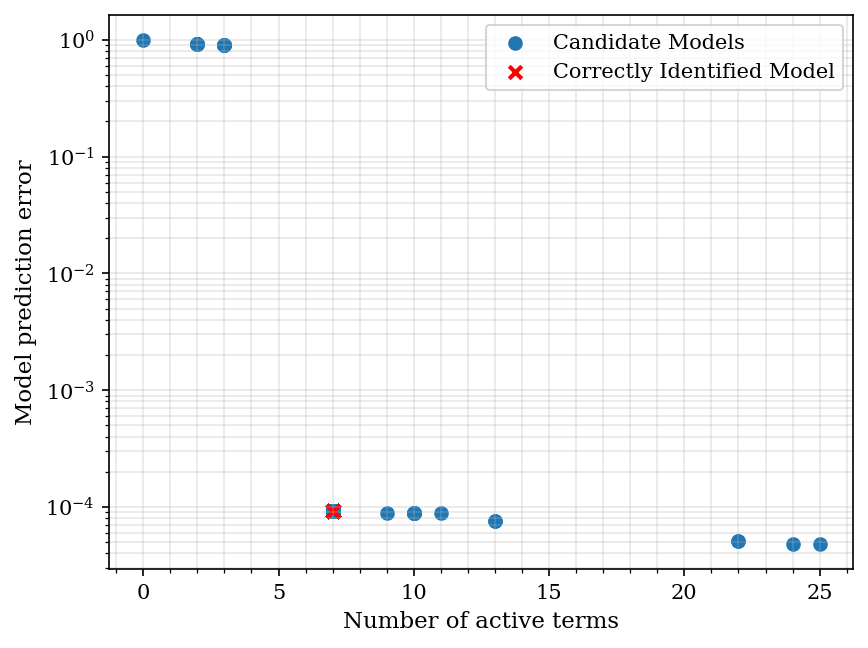

In [ ]:
# Specify the lambda values to sweep
lambdas = np.logspace(-5, 1, 100)

# The number of non-zero terms in the Lorenz equation
n_lorenz_terms = 7

# Sweep through the specified hyperparameters
pred_errors = list()
active_terms = list()
xis = list()

for lam in lambdas:
    xi = stlsq(lib, xdot, lam)
    xis.append(xi)
    pred_errors.append(rel_fro_err(lib @ xi, xdot))
    active_terms.append(np.count_nonzero(xi))

# Identify the correct models
correct_idx = np.where(np.array(active_terms) == n_lorenz_terms)[0]

# Visualise the Pareto front
plt.scatter(active_terms, pred_errors, label='Candidate Models')
plt.scatter(
    np.array(active_terms)[correct_idx], np.array(pred_errors)[correct_idx],
    color='red', marker='x', label='Correctly Identified Model'
)
plt.xlabel('Number of active terms')
plt.ylabel('Model prediction error')
plt.yscale('log')
plt.legend();

Hence, a right balance must be struck between high sparsification threshold (simple models with very few terms) and low sparsification threshold (complex models with many excess terms).